In [17]:
import tensorflow as tf
from pathlib import Path

In [18]:
BASE_DIR = Path("../../")

TRAIN_DIR = BASE_DIR / "dataset/classification/train"
VAL_DIR = BASE_DIR / "dataset/classification/val"
TEST_DIR = BASE_DIR / "dataset/classification/test"

In [19]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(224,224),
    batch_size=16,
    label_mode="binary"
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(224,224),
    batch_size=16,
    label_mode="binary"
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(224,224),
    batch_size=16,
    label_mode="binary"
)

Found 1080 files belonging to 2 classes.


Found 270 files belonging to 2 classes.
Found 339 files belonging to 2 classes.


In [20]:
print(class_names)

['Cancerous', 'non-Cancerous']


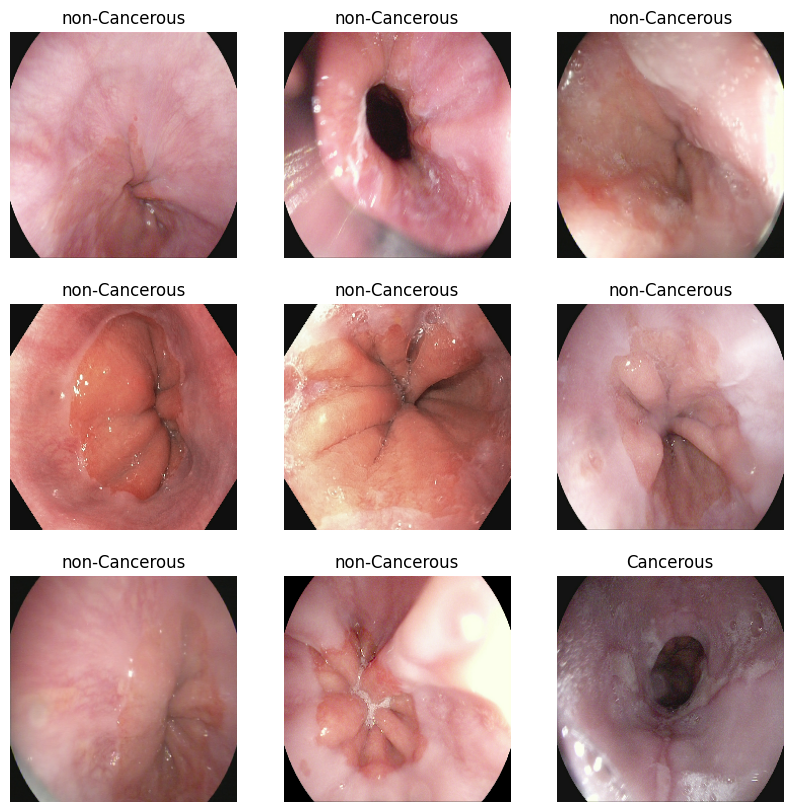

In [21]:
# Plotting Some Random Images from the Dataset

import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(10,10))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])

        plt.title(class_names[label])
        plt.axis("off")

    plt.show()

In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# =========================================================
# Data Augmentation
# =========================================================

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

# =========================================================
# Base Model
# =========================================================

base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)

)

base_model.trainable = False

# =========================================================
# Final Model
# =========================================================

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

# =========================================================
# Compile
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]

)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        patience=2,
        factor=0.2
    ),

    ModelCheckpoint(
        filepath="../../models/classification/best_model.keras",
        save_best_only=True
    )

]

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=20,

    callbacks=callbacks

)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 310ms/step - accuracy: 0.5000 - loss: 0.7136 - precision_1: 0.5586 - recall_1: 0.4480 - val_accuracy: 0.6111 - val_loss: 0.6602 - val_precision_1: 0.6410 - val_recall_1: 0.6711 - learning_rate: 1.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 280ms/step - accuracy: 0.6167 - loss: 0.6642 - precision_1: 0.6458 - recall_1: 0.6762 - val_accuracy: 0.6852 - val_loss: 0.6375 - val_precision_1: 0.6739 - val_recall_1: 0.8322 - learning_rate: 1.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 283ms/step - accuracy: 0.6333 - loss: 0.6389 - precision_1: 0.6404 - recall_1: 0.7651 - val_accuracy: 0.6963 - val_loss: 0.6202 - val_precision_1: 0.6791 - val_recall_1: 0.8523 - learning_rate: 1.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 277ms/step - accuracy: 0.6722 - loss: 0.6182 - precision_1: 0.6734 - recall_1: 0.7886 - val_accuracy: 0.7111 - val_loss: 0.6050 - val_precision_1: 0.6961 - val_recall_1: 0.8456 - learning_rate: 1.0000e-04
Epoch 5/20
6

In [13]:
model.save("../../models/classification/efficientnet_best.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!
